---
title: "Single Banana"
subtitle: "Introductory Example"
format: 
    html: 
        toc: true
execute: 
  enabled: true
code-annotations: hover
bibliography: "../../references.bib"
jupyter: python3
---

In this example, we provide an introduction to the key features of $\texttt{deep\_tensor}$ by using it to approximate and sample from a simple two-dimensional probability density.

## Problem Setup

We consider the banana-shaped density given by
$$
    \pi_{X}(\boldsymbol{x}) \propto \exp\left(\frac{1}{2}(x_{1}^{2} + x_{2}^{2}) + \frac{1}{0.08}(x_{2} - x_{1}^{2} + 2.0)^{2}\right).
$$
We will construct a DIRT approximation to this using $\texttt{deep\_tensor}$.

## Implementation in $\texttt{deep\_tensor}$

We begin by importing $\texttt{deep\_tensor}$ and $\texttt{PyTorch}$.

In [1]:
import torch
from torch import Tensor
import deep_tensor as dt

We also set the random seed, the default device to carry out computations on, and the default datatype to use.

:::{.callout-important}
## Datatypes

We highly recommend that double precision (*i.e.*, the `torch.float64` datatype) is used when working with $\texttt{deep\_tensor}$. If single precision (*i.e.*, the `torch.float32` datatype) is used, floating point errors can compound significantly when evaluating the inverse Rosenblatt transport, particularly when the parameter dimension is high.
:::

In [2]:
torch.manual_seed(0)
torch.set_default_device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

Next, we define a function that evaluates the negative logarithm of the (unnormalised) target density at a set of samples.

:::{.callout-note collapse="true"}
## Inputs and outputs of the target function

The function that evaluates the negative logarithm of the (unnormalised) target density should accept as input a two-dimensional tensor where each row contains a realisation of the parameters, and return a one-dimensional tensor where each element contains the negative logarithm of the (unnormalised) target density for the corresponding row of the input tensor. 

Where possible (for example, when forming the tensor train cores) $\texttt{deep\_tensor}$ will pass a large batch of realisations of the parameters to this function. This allows the user to parallelise evaluations of the target density where possible.
:::

In [3]:
def eval_neglogfx(xs: Tensor) -> Tensor:
    neglogfxs = (
        (1/2) * (xs[:, 0]**2 + xs[:, 1]**2) 
        + (1/0.08) * (xs[:, 1] - xs[:, 0]**2 + 2.0)**2
    )
    return neglogfxs

The target density is plotted in @fig-density.

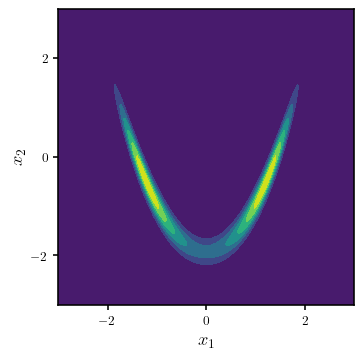

In [4]:
#| code-fold: true
#| fig-align: center
#| fig-cap: The banana-shaped target density.
#| label: fig-density

from matplotlib import pyplot as plt
from examples.plotting import set_plot_style

set_plot_style()

num_xs = 200
xs = torch.linspace(-3.0, 3.0, num_xs)
xs_grid = torch.tensor([[x0, x1] for x1 in xs for x0 in xs])
neglogfxs_grid = eval_neglogfx(xs_grid).reshape(num_xs, num_xs)
fxs_grid = torch.exp(-neglogfxs_grid)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.contourf(xs, xs, fxs_grid)

ax.set_xlabel(r"$x_{1}$")
ax.set_ylabel(r"$x_{2}$")
ax.set_box_aspect(1)
ax.set_xticks([-2, 0, 2])
ax.set_yticks([-2, 0, 2])

plt.show()

## Constructing a DIRT Approximation

### Target Function

To construct a DIRT approximation to this density function, we begin by initialising a `dt.TargetFunc` object with our previously-defined function.

In [5]:
target_func = dt.TargetFunc(eval_neglogfx)

### Reference Density and Preconditioner

Next, we specify an appropriate reference density and preconditioner. 

A standard Gaussian reference density is an appropriate choice of reference density in almost all cases. 

The preconditioner is an initial guess as to the form of the transport map; the subsequent DIRT approximation is constructed to approximate the pullback of the target density under the preconditioning mapping. In this case, the target density can be expressed as the product of a standard Gaussian density and an additional function, so in the absence of any further information an identity mapping is probably appropriate here.

In [6]:
reference = dt.GaussianReference()
preconditioner = dt.IdentityMapping(dim=2, reference=reference)

### Functional Tensor Train Approximations

Next, we will specify the parameters of the functional tensor train (FTT) approximations that will be used to construct each layer of the DIRT mapping. 

We begin with the underlying tensor train decomposition. Here we will construct each tensor train decomposition using two iterations of the cross approximation algorithm [@Oseledets2010] with AMEn enrichment [@Dolgov2014], and the ranks of each core set to an initial value of 8. 

:::{.callout-note collapse="true"}
## Tensor train parameters

For the full set of customisable parameters of the underlying tensor train decomposition, see the documentation for $\texttt{dt.TTOptions}$.
:::

In [7]:
tt_options = dt.TTOptions(tt_method="amen", max_als=2, init_rank=8)
tt = dt.TT(tt_options)

Next, we specify the set of basis functions to use in each dimension of the FTT approximation. Here we use a basis comprised of Legendre polynomials in each dimension. 

The maximum degree of the polynomials is 19, which corresponds to a tensor-product grid with 20 interpolation points in each dimension.

In [8]:
basis = dt.Legendre(order=19)

We initialise an FTT object using this information on the tensor train decomposition and basis functions.

In [9]:
ftt = dt.FTT(basis, tt)

### Bridging Densities

Next, we specify the structure of the bridging densities that will be approximated at each iteration of the DIRT algorithm. 

In this case, we define the bridging densities using a tempering approach. We will let $\rho(\cdot)$ denote the standard Gaussian reference density. Then, the bridging densities $\{\pi_{X^{(k)}}(\cdot)\}_{k=1}^{K}$ take the form
$$
    \pi_{X^{(k)}}(\boldsymbol{x}) \propto \rho(\boldsymbol{x})^{1-\beta_{k}}\pi_{X}(\boldsymbol{x})^{\beta_{k}}, \qquad k \in \{1, \dots, K\},
$$
where the coefficients $\{\beta_{k}\}_{k=1}^{K}$ satisfy $0 \leq \beta_{1} < \cdots < \beta_{K} = 1$.

We define the values of the coefficients $\{\beta_{k}\}_{k=1}^{K}$ using a geometric sequence.

In [10]:
K = 4
betas = torch.logspace(-1.5, 0.0, K)
bridge = dt.Tempering(betas)

### DIRT Approximation

Finally, we compute and store the associated DIRT approximation.

:::{.callout-note collapse="true"}
## Diagnostic information printed during DIRT construction

By default, during the construction of a DIRT approximation some output will be printed to the screen. 

The `[DIRT]` output below includes, at each iteration (from left to right)

 - the current iteration number, $k$;
 - the cumulative number of function evaluations (including for the construction of FTT approximations and diagnostic purposes) made;
 - the cumulative time taken;
 - the tempering parameter $\beta$ associated with the current bridging density;
 - an estimate of the Hellinger distance between bridging density $k-1$ and its DIRT approximation; and
 - an estimate of the effective sample size (ESS) between a set of samples from the DIRT approximation to bridging density $k-1$, and bridging density $k$ (if this diagnostic is very low, it suggests that successive bridging densities are not similar in form to one another, so a larger number of bridging densities may be required).

The `[ALS]` output below includes, at each iteration (from left to right)

 - the iteration number of the cross approximation algorithm, $\ell$; 
 - the total number of functional evaluations made to form the current tensor train approximation;
 - the maximum rank of all tensor cores;
 - $\max_{i} \Delta^{(\ell)}_{i}$, where $\Delta^{(\ell)}_{i}$ is defined below;
 - $\frac{1}{d}\sum_{i=1}^{d} \Delta^{(\ell)}_{i}$, where $\Delta^{(\ell)}_{i}$ is defined below; and 
 - an sample-based estimate of the $L^{2}$ error between the target function and the FTT approximation.

The quantity $\Delta^{(\ell)}_{i}$ is defined as
$$
    \Delta^{(\ell)}_{i} := \frac{||\boldsymbol{H}^{(\ell)}_{i} - \boldsymbol{H}^{(\ell)}_{i}||_{\infty}}{||\boldsymbol{H}^{(\ell)}_{i}||_{\infty}}
$$
where $\boldsymbol{H}^{(\ell)}_{i}$ denote the $i$-th tensor core at iteration $\ell$ of the cross approximation algorithm.
:::

In [11]:
dirt = dt.DIRT(target_func, preconditioner, ftt, bridge)

[DIRT] Iter:  1 | Cum. Fevals: 1.00e+03 | Cum. Time: 7.69e-03 s | Beta: 0.0316 | DHell: 0.0000 | ESS: 0.6330
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error


[ALS]     1 |       1400 |       10 |       1.00e+00 |        1.00e+00 | 1.61e-02
[ALS]     2 |       1880 |       12 |       4.36e-06 |        2.18e-06 | 1.61e-02
[ALS]  ALS complete.
[DIRT] Iter:  2 | Cum. Fevals: 3.88e+03 | Cum. Time: 4.27e-01 s | Beta: 0.1000 | DHell: 0.0091 | ESS: 0.7488
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       1400 |       10 |       2.36e-01 |        1.20e-01 | 1.29e-02
[ALS]     2 |       1880 |       12 |       2.62e-04 |        1.31e-04 | 1.29e-02
[ALS]  ALS complete.
[DIRT] Iter:  3 | Cum. Fevals: 6.76e+03 | Cum. Time: 5.16e-01 s | Beta: 0.3162 | DHell: 0.0111 | ESS: 0.7044
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       1400 |       10 |       2.24e-01 |        1.14e-01 | 2.56e-02


[ALS]     2 |       1880 |       12 |       2.41e-05 |        1.20e-05 | 2.56e-02
[ALS]  ALS complete.
[DIRT] Iter:  4 | Cum. Fevals: 9.64e+03 | Cum. Time: 6.59e-01 s | Beta: 1.0000 | DHell: 0.0219 | ESS: 0.7084
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       1400 |       10 |       4.20e-01 |        2.10e-01 | 3.42e-02
[ALS]     2 |       1880 |       12 |       1.41e-06 |        7.06e-07 | 3.42e-02
[ALS]  ALS complete.


[DIRT]  • DIRT construction complete.
[DIRT]  • Layers: 4.
[DIRT]  • Total function evaluations: 12,520.
[DIRT]  • DHell: 0.0361.
[DIRT]  • Total time: 0.86 secs.


## Density Evaluation and Sampling

Now that we have constructed the DIRT approximation to the target density, we can sample from it.

The below code illustrates how we can sample from the DIRT approximation. We first generate a set of samples from the reference density, then apply the `eval_irt` method of the DIRT object to transform them such that they are distributed according to the DIRT approximation to the target density. Note that the `eval_irt` method returns both the samples after applying the inverse Rosenblatt transport, and the (normalised) DIRT approximation to the target density evaluated at each sample.

In [12]:
rs = reference.random(n=10, d=dirt.dim)
xs_dirt, neglogfxs_dirt = dirt.eval_irt(rs)

We can also compute the value of the DIRT approximation to the target density for various values of the parameters. The below code evaluates the DIRT density on a grid of parameter values.

In [13]:
num_xs = 200
xs = torch.linspace(-3.0, 3.0, num_xs)
xs_grid = torch.tensor([[x0, x1] for x1 in xs for x0 in xs])

fxs_dirt_grid = dirt.eval_pdf(xs_grid).reshape(num_xs, num_xs)

@fig-density-dirt provides a comparison between the target density and its DIRT approximation.

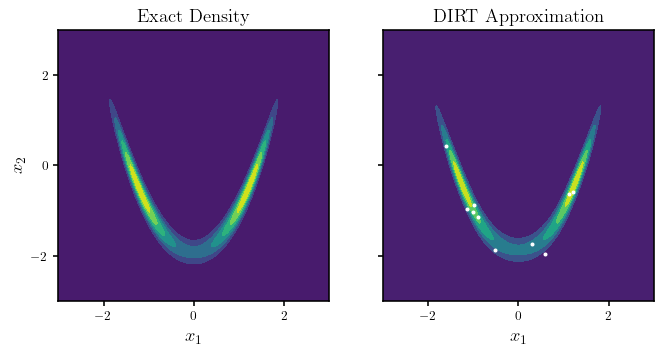

In [14]:
#| code-fold: true
#| fig-align: center
#| fig-cap: The target density (left) and the corresponding DIRT approximation (right). Some samples distributed according to the DIRT approximation are shown in white on the right-most plot.
#| label: fig-density-dirt

neglogfxs_grid = eval_neglogfx(xs_grid).reshape(num_xs, num_xs)
fxs_grid = torch.exp(-neglogfxs_grid)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

axes[0].contourf(xs, xs, fxs_grid)
axes[1].contourf(xs, xs, fxs_dirt_grid)
axes[1].scatter(*xs_dirt.T, c="white", s=4)

axes[0].set_title("Exact Density")
axes[1].set_title("DIRT Approximation")

axes[0].set_ylabel(r"$x_{2}$")

for ax in axes:
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$x_{1}$")
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([-2, 0, 2])

plt.show()

## Debiasing: Importance Sampling and MCMC

In this simple example, the DIRT approximation to the target density is already very accurate. However, in some instances we may wish to correct for the bias associated with the use of an imperfect approximation to the target density. This can be done by incorporating the DIRT approximation into an importance sampling or Markov chain Monte Carlo (MCMC) algorithm.

### Importance Sampling

We begin by using the DIRT density as a proposal density for importance sampling.

In [15]:
rs = dirt.reference.random(n=10_000, d=dirt.dim)                        # <1>
xs, neglogfxs_dirt = dirt.eval_irt(rs)

neglogfxs_true = eval_neglogfx(xs)                                      # <2>

res = dt.run_importance_sampling(neglogfxs_dirt, neglogfxs_true)        # <3>
log_weights = res.log_weights                                           # <4>

print(f"ESS: {res.ess:.2f}.")

ESS: 9897.73.


1. Use the `eval_irt` method to transform a set of samples from the reference density such that they are distributed according to the DIRT approximation to the target density, and evaluate the negative logarithm of the DIRT density at each sample
2. Evaluate the negative logarithm of the (unnormalised) exact density at each sample
3. Run the DIRT-IS algorithm
4. Extract the computed importance weights

The high effective sample size (ESS) provides further evidence that the DIRT approximation is very accurate.

### MCMC

As an alternative, we can use the DIRT approximation as part of an MCMC sampler. The below code illustrates how we can use the DIRT approximation to provide proposals for an independence MCMC sampler.

In [16]:
rs = dirt.reference.random(n=10_000, d=dirt.dim)                        # <1>
xs, neglogfxs_dirt = dirt.eval_irt(rs)

neglogfxs_true = eval_neglogfx(xs)                                      # <2>

res = dt.run_independence_sampler(xs, neglogfxs_dirt, neglogfxs_true)   # <3>
xs_chain = res.xs                                                       # <4>

print(f"Acceptance rate: {res.acceptance_rates[0]:.2f}.")

Acceptance rate: 0.94.


1. Use the `eval_irt` method to transform a set of samples from the reference density such that they are distributed according to the DIRT approximation to the target density, and evaluate the negative logarithm of the DIRT density at each sample
2. Evaluate the negative logarithm of the (unnormalised) exact density at each sample
3. Run an independence MCMC sampler using the DIRT approximation as a proposal density
4. Extract the computed Markov chain

As expected, the acceptance rate of the sampler is high.